## Synthetic experiment

In [15]:
import nest_asyncio
nest_asyncio.apply()
import stan
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Simulate the network

In [16]:
# --- parameters to mimic your data ---
np.random.seed(42)
T = 21219

#this is the decay parameter beta in the paper
gamma = np.array([
    [0.1, 1],
    [2.5, 0.2]
])

alpha = np.array([
    [0.35, 0.6],
    [0.1, 0.2]
])

# baseline rates  ~200 total events
mu = np.array([0.0037, 0.0020])

times = []
marks = []

# baseline events
N = np.random.poisson(np.sum(mu) * T)

for i in range(N):
    t = T * np.random.rand()
    times.append(t)
    if np.random.rand() < mu[0] / np.sum(mu):
        marks.append(0)
    else:
        marks.append(1)

# --- branching process ---
cnt = 0
while cnt < N:
    k = marks[cnt]

    # offspring type 0
    M = np.random.poisson(alpha[0, k])
    for _ in range(M):
        tnew = times[cnt] + np.random.exponential(1.0 / gamma[0, k])
        if tnew < T:
            times.append(tnew)
            marks.append(0)
            N += 1

    # offspring type 1
    M = np.random.poisson(alpha[1, k])
    for _ in range(M):
        tnew = times[cnt] + np.random.exponential(1.0 / gamma[1, k])
        if tnew < T:
            times.append(tnew)
            marks.append(1)
            N += 1

    cnt += 1

# sort events
times, marks = (list(t) for t in zip(*sorted(zip(times, marks))))

Na = sum(np.array(marks) == 0)
Nb = sum(np.array(marks) == 1)
print("Total events:", len(times))
print(Na)
print(Nb)

Total events: 247
174
73


In [19]:
times0=[]
times1=[]
for i in range(len(times)):
    if(marks[i]==0):
        times0.append(times[i])
    else:
        times1.append(times[i])

times0=times0
times1=times1

### Parameter estimation

In [21]:
model_code = """
data {
  int<lower=1> Na;
  int<lower=1> Nb;
  array[Na] real ta;
  array[Nb] real tb;  
  real<lower = 0> T;
}
parameters {
  
  vector<lower=0>[2] mu;
  matrix<lower=0>[2,2] gamma;
  matrix<lower=0, upper=1>[2,2] alpha;
}
transformed parameters {

  vector[Na] lam_a;
  vector[Nb] lam_b;

  lam_a[1] = mu[1];
  lam_b[1] = mu[2];

  for (j in 2:Na){
    lam_a[j] = mu[1];
    for (k in 1:(j-1)){
      lam_a[j] += alpha[1,1]*gamma[1,1]*exp(-gamma[1,1]*(ta[j]-ta[k]));
    }
    for (k in 1:Nb){
      if (ta[j]>tb[k]) {
        lam_a[j] += alpha[1,2]*gamma[1,2]*exp(-gamma[1,2]*(ta[j]-tb[k]));
      }
    }
  }

  for (j in 2:Nb){
    lam_b[j] = mu[2];
    for (k in 1:(j-1)){
      lam_b[j] += alpha[2,2]*gamma[2,2]*exp(-gamma[2,2]*(tb[j]-tb[k]));
    }
    for (k in 1:Na){
      if (tb[j]>ta[k]) {
        lam_b[j] += alpha[2,1]*gamma[2,1]*exp(-gamma[2,1]*(tb[j]-ta[k]));
      }
    }
  }
}

model {

  alpha[1,1] ~ beta(1,1);
  alpha[2,2] ~ beta(1,1);
  alpha[1,2] ~ beta(1,1);
  alpha[2,1] ~ beta(1,1);

  for (j in 1:Na){
     mu[1] ~ cauchy(0, 5);}
  for (j in 1:Na){
     mu[2] ~ cauchy(0, 5);}

  gamma[1,1] ~ lognormal(log(.1), .5);  
  gamma[2,2] ~ lognormal(log(.2), .5);  
  gamma[1,2] ~ lognormal(log(1.), .5);   
  gamma[2,1] ~ lognormal(log(2.5), .5);

  for (j in 1:Na)
    target += log(lam_a[j]);
  
  for (j in 1:Nb)
    target += log(lam_b[j]);

  target += -mu[1]*T - mu[2]*T -(alpha[1,1]+alpha[2,1])*Na -(alpha[1,2]+alpha[2,2])*Nb; 
}
"""


In [22]:
hawkes_data = {"Na":Na , "Nb":Nb, "ta": times0, "tb": times1, "T":T}
posterior = stan.build(model_code, data=hawkes_data, random_seed=1)
fit = posterior.sample(num_chains=1, num_samples= 1000)


Building: 0.2s
Building: 0.3s
Building: 0.4s
Building: 0.5s
Building: 0.6s
Building: 0.7s
Building: 0.8s
Building: 0.9s
Building: 1.0s
Building: 1.1s
Building: 1.2s
Building: 1.3s
Building: 1.4s
Building: 1.5s
Building: 1.6s
Building: 1.7s
Building: 1.8s
Building: 1.9s
Building: 2.0s
Building: 2.1s
Building: 2.2s
Building: 2.4s
Building: 2.5s
Building: 2.6s
Building: 2.7s
Building: 2.8s
Building: 2.9s
Building: 3.0s
Building: 3.1s
Building: 3.2s
Building: 3.3s
Building: 3.4s
Building: 3.5s
Building: 3.6s
Building: 3.7s
Building: 3.8s
Building: 3.9s
Building: 4.0s
Building: 4.1s
Building: 4.2s
Building: 4.3s
Building: 4.4s
Building: 4.5s
Building: 4.6s
Building: 4.7s
Building: 4.8s
Building: 5.0s
Building: 5.1s
Building: 5.2s
Building: 5.3s
Building: 5.4s
Building: 5.5s
Building: 5.6s
Building: 5.7s
Building: 5.8s
Building: 5.9s
Building: 6.0s
Building: 6.1s
Building: 6.2s
Building: 6.3s
Building: 6.4s
Building: 6.5s
Building: 6.6s
Building: 6.7s
Building: 6.8s
Building: 6.9s
Building: 

Building: 25.0s, done.
Messages from stanc:
Sampling:   0%
Sampling:   0% (1/2000)
Sampling:   5% (100/2000)
Sampling:  10% (200/2000)
Sampling:  15% (300/2000)
Sampling:  20% (400/2000)
Sampling:  25% (500/2000)
Sampling:  30% (600/2000)
Sampling:  35% (700/2000)
Sampling:  40% (800/2000)
Sampling:  45% (900/2000)
Sampling:  50% (1000/2000)
Sampling:  50% (1001/2000)
Sampling:  55% (1100/2000)
Sampling:  60% (1200/2000)
Sampling:  65% (1300/2000)
Sampling:  70% (1400/2000)
Sampling:  75% (1500/2000)
Sampling:  80% (1600/2000)
Sampling:  85% (1700/2000)
Sampling:  90% (1800/2000)
Sampling:  95% (1900/2000)
Sampling: 100% (2000/2000)
Sampling: 100% (2000/2000), done.
Messages received during sampling:
  Gradient evaluation took 0.008532 seconds
  1000 transitions using 10 leapfrog steps per transition would take 85.32 seconds.
  Adjust your expectations accordingly!


In [23]:
fit

<stan.Fit>
Parameters:
    mu: (2,)
    gamma: (2, 2)
    alpha: (2, 2)
    lam_a: (174,)
    lam_b: (73,)
Draws: 1000

In [24]:
baseline = np.mean(fit['mu'], axis = 1)
adj = np.mean(fit['alpha'], 2)
decays = np.mean(fit['gamma'], 2) 

In [25]:
gamma[0,1]

np.float64(1.0)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


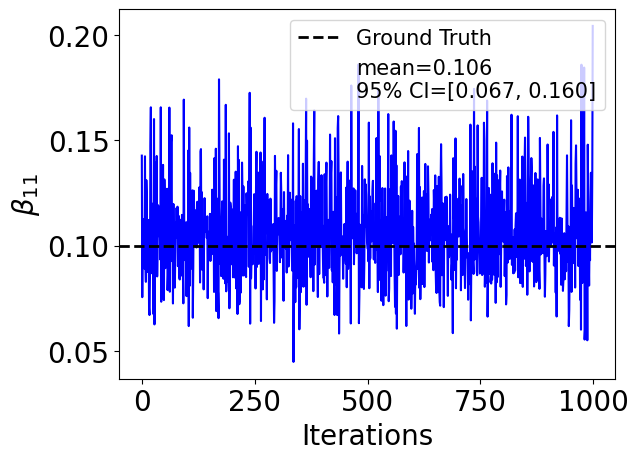

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


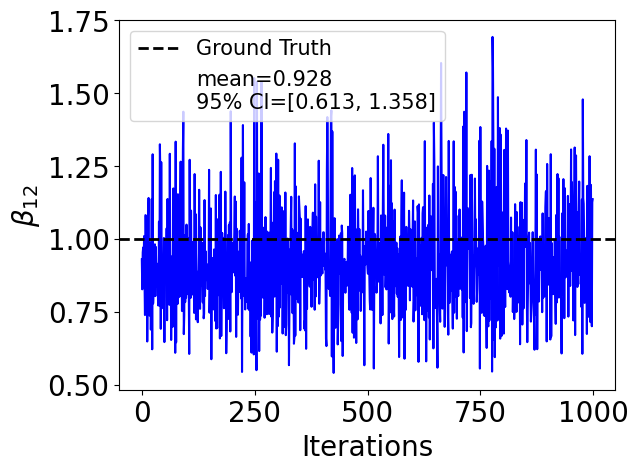

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


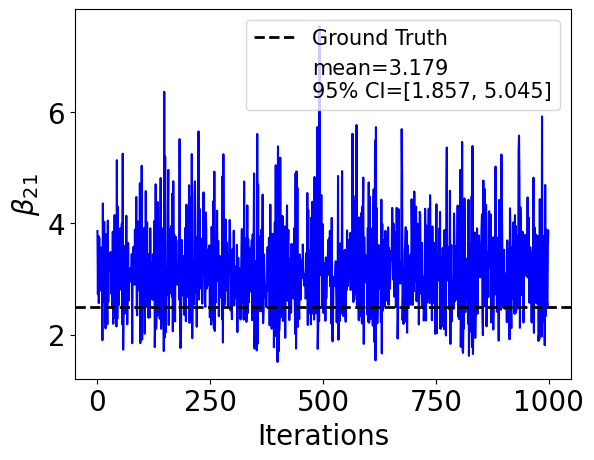

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


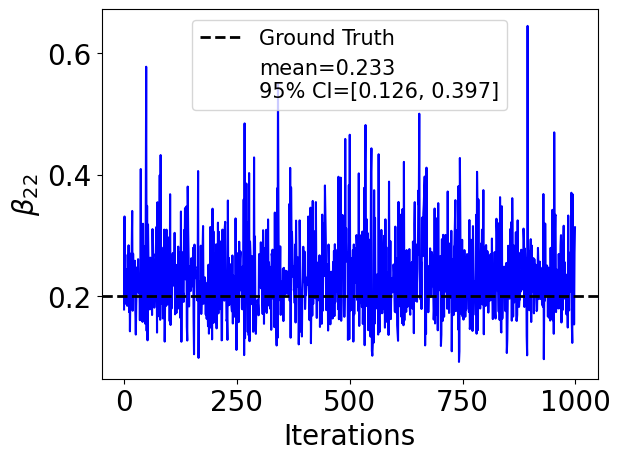

In [26]:
for i in range(2):
    for j in range(2):
        samples = fit['gamma'][i, j, :]
        plt.figure()
        plt.plot(samples, 'b')
        plt.axhline(y=gamma[i, j], color='k', ls='dashed', linewidth = 2, label  = f'Ground Truth')
        # Dummy (invisible) line for mean + CI legend entry
        mean_ci_label = (
            f"mean={np.mean(samples):.3f}\n"
            f"95% CI=[{np.percentile(samples,2.5):.3f}, {np.percentile(samples,97.5):.3f}]"
                        )
        plt.plot([], [], ' ', label=mean_ci_label)
        plt.xlabel('Iterations', fontsize=20)
        plt.ylabel(fr'$\beta_{{{i + 1}{j + 1}}}$', fontsize=20)
        #plt.title('Markov Chain sampling from posterior', fontsize = 20)
        plt.tick_params(axis='x', labelsize=20)
        plt.tick_params(axis='y', labelsize=20)
        plt.legend(fontsize=15)
        plt.savefig(f'mcmc_beta{i + 1}{j + 1}.eps', bbox_inches='tight')
        plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


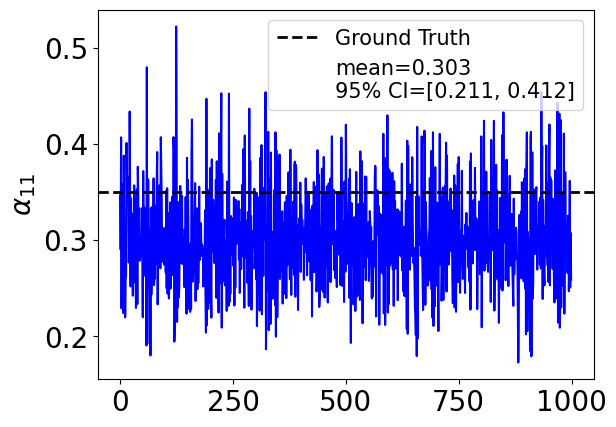

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


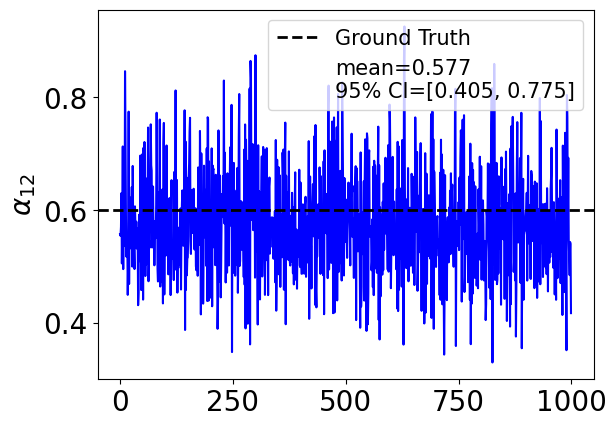

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


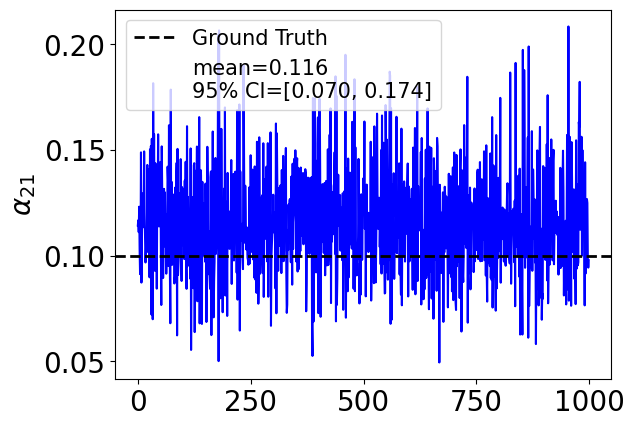

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


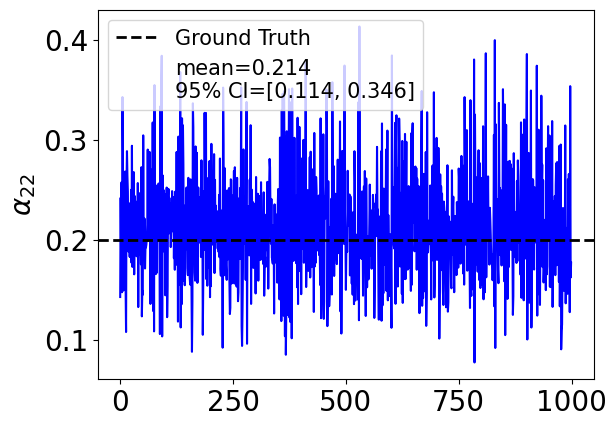

In [27]:
for i in range(2):
    for j in range(2):
        samples = fit['alpha'][i, j, :]
        plt.figure()
        plt.plot(samples, 'b')
        plt.axhline(y=alpha[i, j], color='k', ls='dashed', linewidth = 2, label  = f'Ground Truth')
        mean_ci_label = (
            f"mean={np.mean(samples):.3f}\n"
            f"95% CI=[{np.percentile(samples,2.5):.3f}, {np.percentile(samples,97.5):.3f}]"
                        )
        plt.plot([], [], ' ', label=mean_ci_label)
        plt.ylabel(fr'$\alpha_{{{i + 1}{j + 1}}}$', fontsize=20)
        plt.tick_params(axis='x', labelsize=20)
        plt.tick_params(axis='y', labelsize=20)
        plt.legend(fontsize=15)
        plt.savefig(f'mcmc_alpha{i + 1}{j + 1}.eps', bbox_inches='tight')
        plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


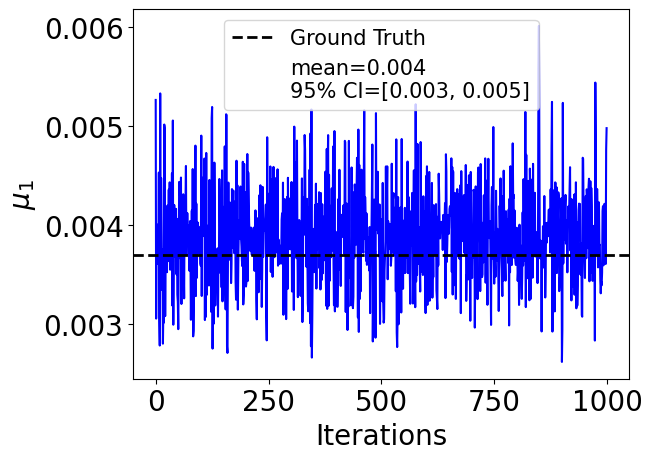

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


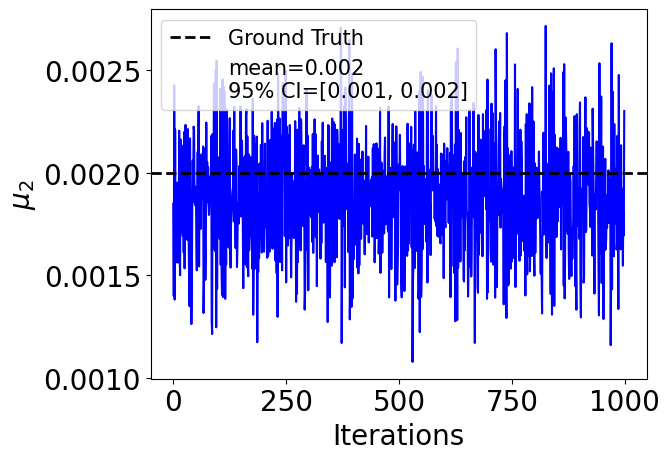

In [28]:
for i in range(2):
    samples = fit['mu'][i, :]
    plt.figure()
    plt.plot(samples, 'b')
    plt.axhline(y=mu[i], color='k', ls='dashed', linewidth = 2, label  = f'Ground Truth')
    mean_ci_label = (
        f"mean={np.mean(samples):.3f}\n"
        f"95% CI=[{np.percentile(samples,2.5):.3f}, {np.percentile(samples,97.5):.3f}]")
    plt.plot([], [], ' ', label=mean_ci_label)
    plt.xlabel('Iterations', fontsize=20)
    plt.ylabel(fr'$\mu_{i + 1}$', fontsize=20)
    plt.tick_params(axis='x', labelsize=20)
    plt.tick_params(axis='y', labelsize=20)
    plt.legend(fontsize=15) 
    plt.savefig(f'mcmc_mu{i + 1}.eps', bbox_inches='tight')
    plt.show()